In [4]:
!pip install nltk

Pet project на основе датасета Banking77
Цель: по сообщению клиента определить какую услугу желает произвести клиент

In [5]:
# импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,f1_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
import os
import joblib

In [6]:
#загрузка данных
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
train.head()

,text,label,label_text
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


В нашем датасете 3 столбца : text,label,label_text . В столбце text мы видим само сообщение клиента (запрос с которым обращается клиент), в столбце label номер к которому при обучении модель должна по сообщению клиента присваивать (грубо говоря номер категории запроса). В столбце label_text в понятном для человека написана категория запроса клиента, которую будет предсказывать модель на тренировачных данных.

In [7]:
print("Train shape:",train.shape)
print("Test shape:",test.shape)


Train shape: (10003, 3)
Test shape: (3080, 3)


В обучающей выборке есть 10 тысяч и 3 строки и 3 столбца, а в тестовой выборке 3 тысячи 80 строк и 3 столбца.

In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        10003 non-null  str  
 1   label       10003 non-null  int64
 2   label_text  10003 non-null  str  
dtypes: int64(1), str(2)
memory usage: 234.6 KB


В нашем обучающей выборке все 3 столбца ненулевые. Столбцы text и label_text имеют тип str, а столбец label имеет тип int 64

In [9]:
train.isnull().sum()

text          0
label         0
label_text    0
dtype: int64

нулевых значений в датасете нет

In [10]:
train.duplicated().sum()

np.int64(0)

дублирующихся значений также нет

In [11]:
train['label_text'].nunique()

77

уникальных категорий (классов) в столбце label_text у нас 77

In [12]:
train['label_text'].unique()

<StringArray>
[                                    'card_arrival',
                                     'card_linking',
                                    'exchange_rate',
                 'card_payment_wrong_exchange_rate',
                        'extra_charge_on_statement',
                          'pending_cash_withdrawal',
                            'fiat_currency_support',
                           'card_delivery_estimate',
                                 'automatic_top_up',
                                 'card_not_working',
                                 'exchange_via_app',
                              'lost_or_stolen_card',
                                        'age_limit',
                                      'pin_blocked',
                          'contactless_not_working',
                   'top_up_by_bank_transfer_charge',
                                   'pending_top_up',
                                  'cancel_transfer',
                                

In [13]:
train['label_text'].value_counts()

label_text
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64

Самыми востребованными запросами являются: card_payment_fee_charged,direct_debit_payment_not_recognised, balance_not_updated_after_cheque_or_cash_deposit,  wrong_amount_of_cash_received, cash_withdrawal_charge. Видно что классы несбалансированы.               

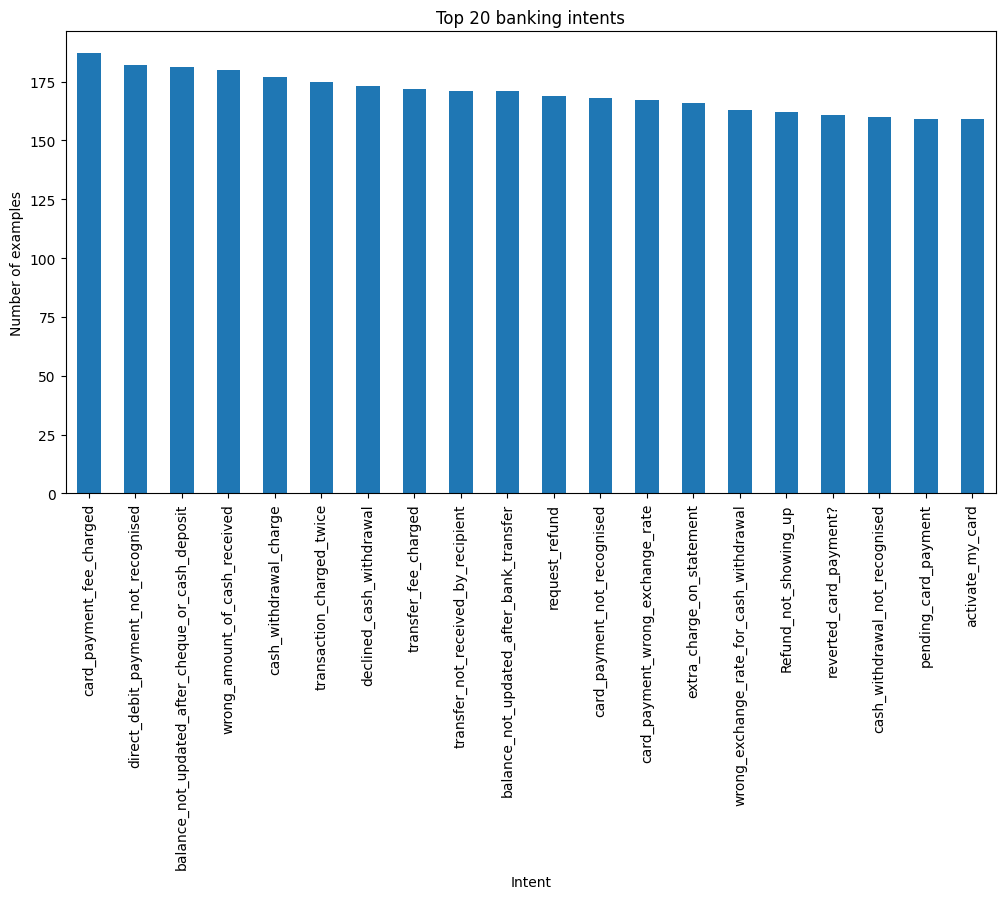

In [14]:
train['label_text'].value_counts().head(20).plot(
    kind='bar',
    figsize=(12,6)
)
plt.title('Top 20 banking intents')
plt.xlabel('Intent')
plt.ylabel('Number of examples')
plt.xticks(rotation=90)
plt.show()

In [15]:
train[['text', 'label_text']].sample(10, random_state=42)

,text,label_text
6883,Is it possible for me to change my PIN number?,change_pin
5836,I'm not sure why my card didn't work,declined_card_payment
8601,I don't think my top up worked,top_up_failed
2545,Can you explain why my payment was charged a fee?,card_payment_fee_charged
8697,How long does a transfer from a UK account tak...,balance_not_updated_after_bank_transfer
5573,Why am I getting declines when trying to make ...,declined_transfer
576,What is the $1 transaction on my account?,extra_charge_on_statement
6832,It looks like my card payment was sent back.,reverted_card_payment?
7111,Why am I unable to transfer money when I was a...,beneficiary_not_allowed
439,What if there is an error on the exchange rate?,card_payment_wrong_exchange_rate


Здесь мы видим рандомную выборку , где по тексту (запросу клиента) видно к чему(к какой категории) модель должна относить сообщение

In [16]:
train['text_length']=train['text'].str.len()
train

,text,label,label_text,text_length
0,I am still waiting on my card?,11,card_arrival,30
1,What can I do if my card still hasn't arrived ...,11,card_arrival,60
2,I have been waiting over a week. Is the card s...,11,card_arrival,58
3,Can I track my card while it is in the process...,11,card_arrival,59
4,"How do I know if I will get my card, or if it ...",11,card_arrival,54
...,...,...,...,...
9998,You provide support in what countries?,24,country_support,38
9999,What countries are you supporting?,24,country_support,34
10000,What countries are getting support?,24,country_support,35
10001,Are cards available in the EU?,24,country_support,30


Создадим новый столбец text_length, где будем подсчитывать длину сообщения клиента посимвольно

In [17]:
train['text_length'].describe()

count    10003.000000
mean        59.473758
std         40.867901
min         13.000000
25%         36.000000
50%         47.000000
75%         64.000000
max        433.000000
Name: text_length, dtype: float64

Самыми длинными посимвольно сообщениями можно назвать сообщения, состоящие из 433 символа, но если говорить о большей части сообщений они состоят от 36 до 64 символов. То есть можно сделать вывод , что длинные сообщения это редкие случаи сообщений. В среднем 59 символов в сообщении с размахом +-40 символов.

In [18]:
train['word_count']=train['text'].str.split().str.len()
train

,text,label,label_text,text_length,word_count
0,I am still waiting on my card?,11,card_arrival,30,7
1,What can I do if my card still hasn't arrived ...,11,card_arrival,60,13
2,I have been waiting over a week. Is the card s...,11,card_arrival,58,12
3,Can I track my card while it is in the process...,11,card_arrival,59,13
4,"How do I know if I will get my card, or if it ...",11,card_arrival,54,15
...,...,...,...,...,...
9998,You provide support in what countries?,24,country_support,38,6
9999,What countries are you supporting?,24,country_support,34,5
10000,What countries are getting support?,24,country_support,35,5
10001,Are cards available in the EU?,24,country_support,30,6


Создадим новый столбец word_count, где будем подсчитывать количество слов в сообщении.

In [19]:
train['word_count'].describe()

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: word_count, dtype: float64

В среднем сообщение состоит из 11 слов c размахом +-7 слов. Большая часть сообщений состоит от 7 до 13 слов.

Text(0.5, 1.0, 'Распределение количества слов в сообщениях')

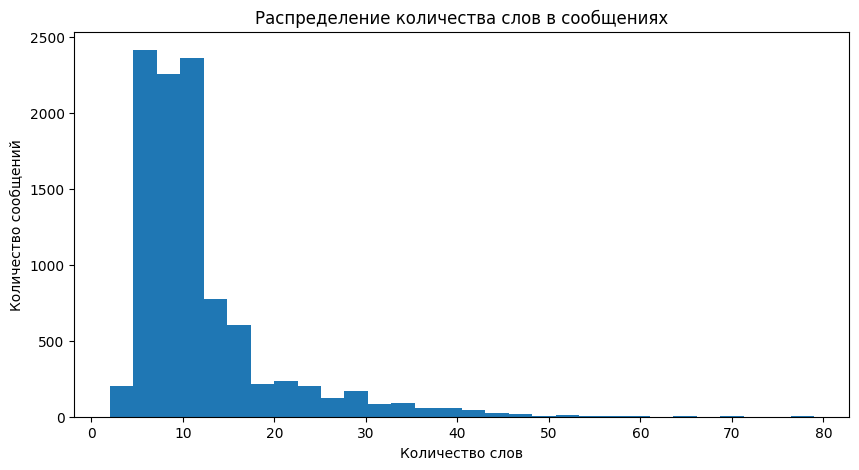

In [20]:
plt.figure(figsize=(10,5))
plt.hist(train['word_count'],bins=30)
plt.xlabel('Количество слов')
plt.ylabel('Количество сообщений')
plt.title('Распределение количества слов в сообщениях')

По графику видно, что большинство сообщений состоят от 5 до 17 слов. Также по графику распределения видно, что есть длинный хвост, распределение далеко от нормального.

In [21]:
train['word_count'].skew()

np.float64(2.613519235767973)

In [22]:
train['word_count'].kurt()

np.float64(9.055118637784945)

In [23]:
train[['text','word_count']].sort_values('word_count').head(10)

,text,word_count
5561,Transfer declined.,2
5176,pending transaction?,2
9979,Supported countries,2
4847,passcode retrieval,2
4889,Lost password,2
2187,Cancel Transaction,2
4003,The card PIN?,3
833,Explain pending transactions.,3
6937,Change my pin?,3
2235,Are top-ups unlimited?,3


Самыми короткими сообщениями клиентов являются:Transfer declined.,pending transaction?,	Supported countries, passcode retrieval	,Lost password	

In [24]:
train[['text','word_count']].sort_values('word_count',ascending=False).head(10)

,text,word_count
3917,Hearing back from us regarding your important ...,79
7310,Hi! I'm a university student studying abroad a...,78
3934,Hearing about your verification results from u...,75
3910,It can take between 10 minutes to an hour befo...,70
3905,You will hear back from us about your verifica...,70
5515,Hello-Can you please help me get a refund from...,69
7229,"I transferred 7,000 to a receiver outside the ...",68
6392,My account shows I have been charged twice for...,66
3932,"If you are waiting for verification, it can ta...",64
751,When I used one of the ATMs in the city centre...,64


Самыми длинными сообщениями клиентов являются:Hearing back from us regarding your important ...,Hi! I'm a university student studying abroad a...,Hearing about your verification results from u..., It can take between 10 minutes to an hour befo...,You will hear back from us about your verifica...

In [25]:
train.groupby('label_text')['word_count'].agg(['count','mean','median','min','max']).sort_values('mean',ascending=False).head(15)

,count,mean,median,min,max
label_text,,,,,
transfer_not_received_by_recipient,171,17.549708,12.0,4,58
transfer_fee_charged,172,17.395349,11.0,4,78
pending_cash_withdrawal,143,16.531469,11.0,3,64
failed_transfer,137,15.992701,10.0,3,54
direct_debit_payment_not_recognised,182,15.989011,12.0,3,58
transaction_charged_twice,175,15.988571,10.0,4,66
Refund_not_showing_up,162,15.808642,10.0,4,50
wrong_exchange_rate_for_cash_withdrawal,163,15.460123,12.0,5,39
cash_withdrawal_not_recognised,160,15.437500,12.0,4,40


По данной таблице можно понять, что по запросам transfer_not_received_by_recipient,transfer_fee_charged,pending_cash_withdrawal клиенты пишут самые длинные по количеству слов сообщения

In [26]:
words=' '.join(train['text']).lower().split()
word_freq=Counter(words)
word_freq.most_common(20)

[('i', 8309),
 ('my', 5684),
 ('to', 4011),
 ('a', 3565),
 ('the', 3497),
 ('is', 2339),
 ('can', 1839),
 ('do', 1730),
 ('card', 1636),
 ('it', 1557),
 ('for', 1534),
 ('how', 1511),
 ('what', 1367),
 ('why', 1233),
 ('and', 1213),
 ('you', 1178),
 ('was', 1089),
 ('have', 975),
 ('not', 953),
 ('in', 944)]

Здесь выведены самые часто повторяющиеся слова, но так как мы не делали очистку от слоп слов в список вошли артикли и союзы.

In [27]:
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
filtered_words = [
    word for word in words
    if word not in stop_words
]
word_freq_no_stopwords = Counter(filtered_words)

word_freq_no_stopwords.most_common(20)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mikaask/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('card', 1636),
 ('money', 920),
 ('transfer', 861),
 ('get', 796),
 ('need', 696),
 ('account', 684),
 ('card?', 653),
 ('payment', 644),
 ('top', 609),
 ('cash', 578),
 ('exchange', 504),
 ('charged', 501),
 ('please', 444),
 ('use', 410),
 ('fee', 372),
 ('would', 347),
 ('still', 345),
 ('long', 343),
 ('atm', 338),
 ('new', 334)]

Самые частоповторяющиеся слова без стоп слов

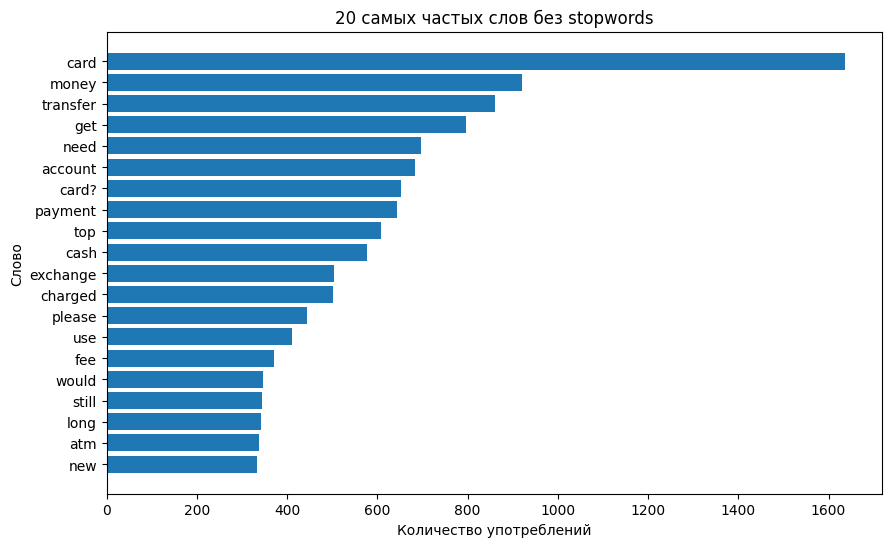

In [28]:
top_words = word_freq_no_stopwords.most_common(20)

words_top = [word for word, count in top_words]
counts_top = [count for word, count in top_words]

plt.figure(figsize=(10, 6))

plt.barh(words_top[::-1], counts_top[::-1])

plt.xlabel('Количество употреблений')
plt.ylabel('Слово')
plt.title('20 самых частых слов без stopwords')

plt.show()

На визуализации более понятно видеть самые частоповторяющиеся слова в запросах.

In [29]:
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words='english'
)

X_bigrams = vectorizer.fit_transform(train['text'])

bigram_counts = X_bigrams.sum(axis=0)

bigrams = [
    (word, bigram_counts[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

sorted(bigrams, key=lambda x: x[1], reverse=True)[:20]

[('exchange rate', np.int64(293)),
 ('new card', np.int64(226)),
 ('card payment', np.int64(202)),
 ('virtual card', np.int64(181)),
 ('cash withdrawal', np.int64(165)),
 ('money account', np.int64(148)),
 ('transfer money', np.int64(118)),
 ('long does', np.int64(109)),
 ('direct debit', np.int64(102)),
 ('extra fee', np.int64(97)),
 ('use card', np.int64(95)),
 ('charged fee', np.int64(94)),
 ('charged extra', np.int64(90)),
 ('change pin', np.int64(86)),
 ('using card', np.int64(85)),
 ('disposable virtual', np.int64(85)),
 ('disposable cards', np.int64(82)),
 ('credit card', np.int64(77)),
 ('cash atm', np.int64(74)),
 ('add money', np.int64(73))]

Здесь мы использовали CountVectorizer, чтобы составить пары слов (словочетаний), которые чаще всего встречаются в сообщениях в нашем датасете. Самыми частоповторяющимися оказались 'exchange rate', 'new card','card payment','virtual card','cash withdrawal'

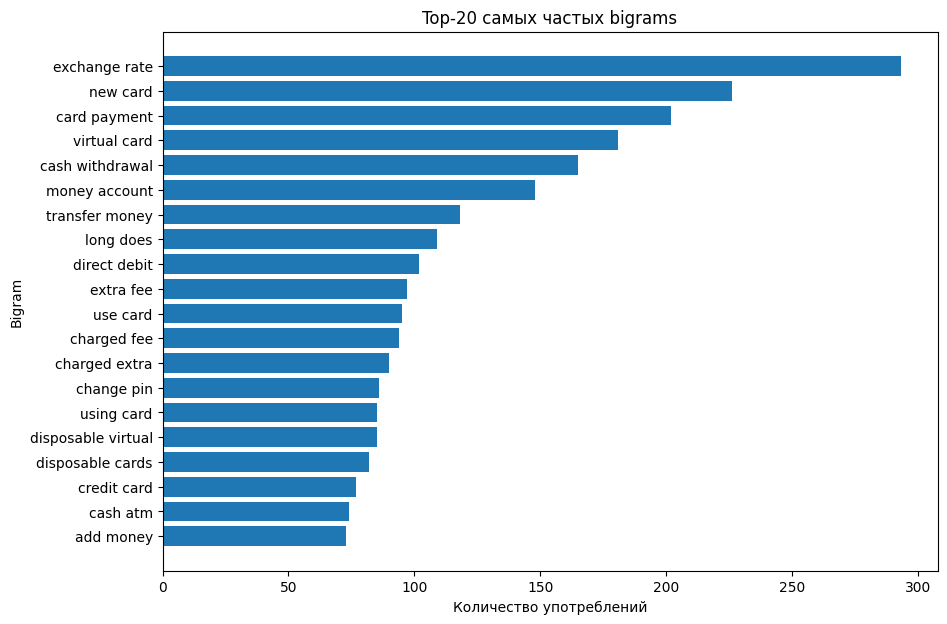

In [30]:
top_bigrams = sorted(
    bigrams,
    key=lambda x: x[1],
    reverse=True
)[:20]

bigram_names = [x[0] for x in top_bigrams]
bigram_counts = [x[1] for x in top_bigrams]

plt.figure(figsize=(10, 7))

plt.barh(bigram_names[::-1], bigram_counts[::-1])

plt.xlabel('Количество употреблений')
plt.ylabel('Bigram')
plt.title('Top-20 самых частых bigrams')

plt.show()

In [31]:
vectorizer = CountVectorizer(
    ngram_range=(3, 3),
    stop_words='english'
)

X_trigrams = vectorizer.fit_transform(train['text'])

trigram_counts = X_trigrams.sum(axis=0)

trigrams = [
    (word, trigram_counts[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

sorted(trigrams, key=lambda x: x[1], reverse=True)[:20]

[('disposable virtual card', np.int64(63)),
 ('exchange rate wrong', np.int64(43)),
 ('transfer money account', np.int64(34)),
 ('charged extra fee', np.int64(33)),
 ('direct debit payment', np.int64(33)),
 ('exchange rate applied', np.int64(27)),
 ('wrong exchange rate', np.int64(26)),
 ('order new card', np.int64(24)),
 ('couple days ago', np.int64(24)),
 ('disposable virtual cards', np.int64(22)),
 ('card payment cancelled', np.int64(22)),
 ('extra fee statement', np.int64(21)),
 ('long does transfer', np.int64(21)),
 ('add money account', np.int64(20)),
 ('card payment declined', np.int64(20)),
 ('card payment reverted', np.int64(19)),
 ('cash withdrawal pending', np.int64(18)),
 ('link new card', np.int64(17)),
 ('exchange rate incorrect', np.int64(17)),
 ('activate new card', np.int64(16))]

Самыми частыми сочетаниями из трех слов являются: 'disposable virtual card', 'exchange rate wrong' , 'transfer money account' , 'charged extra fee', 'direct debit payment'

In [32]:
trigram_names = [x[0] for x in top_trigrams]
trigram_counts = [x[1] for x in top_trigrams]

plt.figure(figsize=(10, 7))

plt.barh(trigram_names[::-1], trigram_counts[::-1])

plt.xlabel('Количество употреблений')
plt.ylabel('Trigram')
plt.title('Top-20 самых частых trigrams')

plt.show()

NameError: name 'top_trigrams' is not defined

In [ ]:
train['label_text'].unique()

<StringArray>
[                                    'card_arrival',
                                     'card_linking',
                                    'exchange_rate',
                 'card_payment_wrong_exchange_rate',
                        'extra_charge_on_statement',
                          'pending_cash_withdrawal',
                            'fiat_currency_support',
                           'card_delivery_estimate',
                                 'automatic_top_up',
                                 'card_not_working',
                                 'exchange_via_app',
                              'lost_or_stolen_card',
                                        'age_limit',
                                      'pin_blocked',
                          'contactless_not_working',
                   'top_up_by_bank_transfer_charge',
                                   'pending_top_up',
                                  'cancel_transfer',
                                

In [ ]:
train[train['label_text'] == 'card_arrival']['text'].head(10)

0                       I am still waiting on my card?
1    What can I do if my card still hasn't arrived ...
2    I have been waiting over a week. Is the card s...
3    Can I track my card while it is in the process...
4    How do I know if I will get my card, or if it ...
5                    When did you send me my new card?
6         Do you have info about the card on delivery?
7    What do I do if I still have not received my n...
8         Does the package with my card have tracking?
9            I ordered my card but it still isn't here
Name: text, dtype: str

In [ ]:
train[train['label_text'] == 'exchange_rate']['text'].head(10)

292           What is my money worth in other countries?
293    Will my money be of equal value when I travel ...
294                    Do you know the rate of exchange?
295    What foreign exchange rate will I get on weekd...
296                   What is the exchange looking like?
297                      How is the exchange rate doing?
298    I would like to know how exchange rates are ca...
299    I would like to know what exchange rates you use?
300    If I need to cash foreign transfers, how does ...
301            Do you know what your exchange rates are?
Name: text, dtype: str

Выше две строчки кода воспредены с целью понять на что вообще модель должна обращать внимания для определения той или иной категории вопроса

Заметка: некоторые категории похожи между собой и модель может перепутать их между собой. Например,
card_payment_not_recognised
cash_withdrawal_not_recognised
direct_debit_payment_not_recognised

In [ ]:
train[train['label_text'] == 'card_payment_not_recognised']['text'].head(10)

3482    There's a payment with my card that I didn't p...
3483    My statement indicates I made a payment to an ...
3484    There's a payment with my card that I definite...
3485    Help! In the app there is a payment that I don...
3486      I don't understand where this charge came from.
3487                   there is a charge i dont recognize
3488    I need to figure out what these charges are on...
3489    Someone might have access to my card!  There a...
3490    There are a couple payments with my card shown...
3491    I'm using the app and I noticed a payment that...
Name: text, dtype: str

In [ ]:
train[train['label_text'] == 'cash_withdrawal_not_recognised']['text'].head(10)

8784    I looked on the app and it says I withdrew cas...
8785    I didn't withdraw the amount of cash that is s...
8786    I saw on the app that a cash withdrawal was co...
8787    I got a notice from my app that I withdrew cas...
8788    Someone has a copy of my card !! I definitely ...
8789          Why do I see a random withdrawal in my app?
8790    Hello, Please look into this matter urgently. ...
8791    Someone has a copy of my card. I have my card ...
8792    There is a withdrawal on my account that I don...
8793    I got a message saying I made a withdrawal fro...
Name: text, dtype: str

In [ ]:
train[train['label_text'] == 'direct_debit_payment_not_recognised']['text'].head(10)

4632    Hi, i found a large amount payment in my old s...
4633                                    what is the word?
4634    Please help my find out why there is an odd di...
4635    I am seeing in the App a diret debit that its ...
4636    There is a direct debit payment that I did not...
4637      There is a strange charge on my debit statement
4638       There is a Direct Debit that looks suspicious.
4639    Is there a way for you to find out why my acco...
4640    Why is there a direct debit payment on my stat...
4641    A direct debit payment that I didn't authorise...
Name: text, dtype: str

В датасете Banking77 присутствуют похожие по смыслу категории,например 'card_payment_not_recognised','cash_withdrawal_not_recognised' и
'direct_debit_payment_not_recognised'.

Все три категории связаны с нераспознанными операциями, однако отличаются типом операции: платеж по карте, снятие наличных и
прямое дебетование соответственно.

Это делает задачу multiclass-классификации более сложной, поскольку модель должна учитывать контекст и сочетания слов, а не только
отдельные ключевые слова.

In [ ]:
unique_words=set(words)
len(unique_words)

4136

In [ ]:
unique_words_no_stopwords=set(filtered_words)
len(unique_words_no_stopwords)

3997

In [ ]:
tfidf = TfidfVectorizer(
    stop_words='english'
)

X_train = tfidf.fit_transform(train['text'])
X_test = tfidf.transform(test['text'])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Vocabulary size:", len(tfidf.get_feature_names_out()))

Train shape: (10003, 2097)
Test shape: (3080, 2097)
Vocabulary size: 2097


In [ ]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:100])
print("Количество признаков:", len(feature_names))
print("Первые 50 слов:")
print(feature_names[:50])

['00' '000' '10' '100' '13' '16' '18' '1818' '1l' '20' '200' '2018' '30'
 '3d' '40' '45' '50' '500' '5x' '60' '80' 'able' 'abroad' 'absolutely'
 'accept' 'acceptable' 'accepted' 'accepting' 'accepts' 'access'
 'accessed' 'accessible' 'accessing' 'accident' 'accidentally'
 'accidently' 'accommodated' 'according' 'accordingly' 'account'
 'accounts' 'accurate' 'achieve' 'acount' 'acquiring' 'acting' 'action'
 'actions' 'activate' 'activated' 'activating' 'activation' 'active'
 'activity' 'actual' 'actually' 'actuate' 'add' 'added' 'adding'
 'addition' 'additional' 'additionally' 'address' 'addressed' 'addressing'
 'adjusted' 'adress' 'advance' 'advertise' 'advise' 'advised' 'affect'
 'afford' 'afraid' 'africa' 'afternoon' 'age' 'agent' 'ages' 'aggravated'
 'ago' 'ahead' 'ahold' 'ain' 'airline' 'airport' 'alert' 'allow'
 'allowable' 'allowance' 'allowances' 'allowed' 'allowing' 'allows' 'alot'
 'alright' 'alter' 'alteration' 'alternative']
Количество признаков: 2097
Первые 50 слов:
['00' '

In [ ]:
text = train['text'].iloc[0]
print(text)
vector = X_train[0]
print(vector)

I am still waiting on my card?
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (1, 2097)>
  Coords	Values
  (0, 2010)	0.9271490383608454
  (0, 275)	0.374692755022778


In [ ]:
row = X_train[0].toarray().flatten()

tfidf_values = pd.DataFrame({
    'word': tfidf.get_feature_names_out(),
    'tfidf': row
})

tfidf_values = tfidf_values[tfidf_values['tfidf'] > 0]
tfidf_values = tfidf_values.sort_values('tfidf', ascending=False)

tfidf_values

,word,tfidf
2010,waiting,0.927149
275,card,0.374693


In [ ]:
words = tfidf.get_feature_names_out()

for index, value in zip(X_train[0].indices, X_train[0].data):
    print(f"{words[index]:<15} → {value:.4f}")

waiting         → 0.9271
card            → 0.3747


На данном этапе текстовые данные были преобразованы в числовой формат с помощью TfidfVectorizer. В качестве stopwords использовался встроенный английский список stop_words='english'.

В результате получили:

Train: 10 003 текстов;
Test: 3 080 текстов;
Vocabulary: 2 097 признаков.

Таким образом, каждый текст теперь представлен в виде числового вектора из 2 097 TF-IDF признаков.
Важно отметить, что vocabulary формировался только на обучающей выборке с помощью:
tfidf.fit_transform(train['text'])

После этого тестовая выборка преобразовывалась с использованием уже созданного словаря:
tfidf.transform(test['text'])

Это позволяет избежать data leakage, поскольку информация из тестовой выборки не используется при формировании признаков.
Как работает TF-IDF
TF-IDF присваивает каждому слову числовой вес, отражающий его значимость для конкретного текста относительно всего корпуса.
Например, для предложения:

I am still waiting on my card?

после удаления stopwords остались информативные слова:
waiting → 0.9271
card    → 0.3747

Слово waiting получило больший вес, поскольку оно встречается в корпусе реже и поэтому является более специфичным признаком, тогда как card является достаточно распространённым словом в банковских запросах.

В результате исходные текстовые данные были успешно преобразованы в числовую разреженную матрицу, которую теперь можно использовать в алгоритмах машинного обучения.

Следующий этап — построение baseline-модели классификации на основе TF-IDF признаков.

In [ ]:
#baseline model
model=LogisticRegression(max_iter=1000)
model.fit(X_train,train['label_text'])
y_pred=model.predict(X_test)
print(y_pred[:10])

['card_arrival' 'card_arrival' 'card_arrival' 'card_arrival'
 'card_arrival' 'order_physical_card' 'card_arrival' 'card_arrival'
 'card_arrival' 'card_arrival']


In [ ]:
accuracy=accuracy_score(test['label_text'],y_pred)
print('Accuracy:',accuracy)

Accuracy: 0.8301948051948052


В качестве первой baseline-модели была выбрана Logistic Regression. Модель обучалась на TF-IDF признаках, полученных из обучающей выборки.

Для оценки качества использовалась тестовая выборка, которая не участвовала в обучении модели.

Полученное значение Accuracy составило 0.83.

Таким образом, даже простая Logistic Regression способна использовать TF-IDF признаки для классификации банковских запросов по 77 категориям.

На следующем этапе проведём более подробную оценку модели с помощью Precision, Recall и F1-score, а также проанализируем Confusion Matrix, чтобы понять, какие категории модель распознаёт хорошо, а какие чаще всего путает.

In [ ]:
print(classification_report(
    test['label_text'],
    y_pred
))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.82      0.93      0.87        40
                                activate_my_card       1.00      0.90      0.95        40
                                       age_limit       0.93      0.97      0.95        40
                         apple_pay_or_google_pay       0.97      0.97      0.97        40
                                     atm_support       0.90      0.93      0.91        40
                                automatic_top_up       0.97      0.90      0.94        40
         balance_not_updated_after_bank_transfer       0.64      0.75      0.69        40
balance_not_updated_after_cheque_or_cash_deposit       0.85      0.88      0.86        40
                         beneficiary_not_allowed       0.89      0.82      0.86        40
                                 cancel_transfer       0.89      0.97      0.93        40
         

В качестве baseline была использована Logistic Regression, обученная на TF-IDF признаках.

На тестовой выборке из 3 080 текстов модель получила следующие результаты:

Accuracy: 0.83
Macro F1-score: 0.83
Weighted F1-score: 0.83

Тестовая выборка содержит по 40 примеров каждого из 77 классов, поэтому она является сбалансированной. В связи с этим значения Macro F1 и Weighted F1 практически совпадают.

Результат F1-score = 0.83 показывает, что базовая модель уже способна достаточно хорошо классифицировать банковские запросы по категориям.

При этом качество существенно различается между отдельными классами. Например, для card_about_to_expire модель получила F1-score 0.99, тогда как для card_acceptance F1-score составил 0.65, а для balance_not_updated_after_bank_transfer — 0.69.

Это показывает, что некоторые категории хорошо разделяются по используемым текстовым признакам, тогда как другие имеют более похожую лексику и чаще вызывают ошибки классификации.

Следующим этапом будет анализ ошибок с помощью Confusion Matrix. Это позволит определить, какие категории модель чаще всего путает между собой, и понять, какие улучшения preprocessing или модели могут повысить качество классификации.

In [ ]:
cm = confusion_matrix(
    test['label_text'],
    y_pred,
    labels=model.classes_
)

In [ ]:
errors = []

for i, true_class in enumerate(model.classes_):
    for j, predicted_class in enumerate(model.classes_):
        
        if i != j and cm[i, j] > 0:
            errors.append({
                'True class': true_class,
                'Predicted class': predicted_class,
                'Errors': cm[i, j]
            })

errors_df = pd.DataFrame(errors)
top_10_errors = errors_df.sort_values(
    'Errors',
    ascending=False
).head(10)

top_10_errors

,True class,Predicted class,Errors
301,virtual_card_not_working,get_disposable_virtual_card,14
296,verify_my_identity,why_verify_identity,10
309,why_verify_identity,verify_my_identity,9
302,virtual_card_not_working,getting_virtual_card,7
143,fiat_currency_support,exchange_via_app,6
28,card_acceptance,card_not_working,6
120,disposable_card_limits,get_disposable_virtual_card,6
200,request_refund,Refund_not_showing_up,6
219,top_up_by_bank_transfer_charge,transfer_fee_charged,6
291,unable_to_verify_identity,verify_my_identity,5


Для более детального анализа качества Logistic Regression были рассмотрены 10 наиболее частых ошибок классификации.

Наиболее частая ошибка наблюдается при классификации virtual_card_not_working как get_disposable_virtual_card — 14 случаев. Также модель часто путает verify_my_identity и why_verify_identity (10 и 9 случаев соответственно).

Большинство наиболее частых ошибок возникает между классами, которые используют похожую лексику и относятся к близким по смыслу банковским операциям. Например, card_acceptance и card_not_working связаны с использованием банковской карты, а fiat_currency_support и exchange_via_app — с валютными операциями.

Особенно показательной является группа intent, связанных с виртуальными картами и верификацией личности. В этих случаях различие между классами определяется не столько отдельными словами, сколько контекстом и намерением пользователя.

Это является ограничением подхода TF-IDF: модель учитывает статистическую важность отдельных слов, но не понимает семантику текста и взаимосвязь слов в контексте.

Таким образом, проведённый анализ ошибок показывает направления для дальнейшего улучшения модели. На следующем этапе будет выполнена настройка гиперпараметров Logistic Regression, после чего её результаты будут сравнены с другими алгоритмами классификации текста.

In [ ]:
logreg=LogisticRegression(max_iter=1000)
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search.fit(
    X_train,
    train['label_text']
)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

test_accuracy = accuracy_score(
    test['label_text'],
    y_pred_best
)

test_f1 = f1_score(
    test['label_text'],
    y_pred_best,
    average='macro'
)

print("Test Accuracy:", test_accuracy)
print("Test Macro F1:", test_f1)

Best parameters: {'C': 10}
Best CV F1: 0.8312097061846515
Test Accuracy: 0.8551948051948052
Test Macro F1: 0.8548123203568556


После обучения лучшей модели и оценки на отдельной тестовой выборке были получены следующие результаты:

Test Accuracy: 0.8552
Test Macro F1: 0.8548

По сравнению с baseline Logistic Regression, которая показала Accuracy и Macro F1 около 0.83, оптимизация позволила повысить качество классификации примерно на 2.5 процентного пункта по Macro F1.

Таким образом, настройка гиперпараметра C позволила улучшить качество Logistic Regression.

In [ ]:
svm_model = LinearSVC()

svm_model.fit(
    X_train,
    train['label_text']
)

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(
    test['label_text'],
    y_pred_svm
)

svm_f1 = f1_score(
    test['label_text'],
    y_pred_svm,
    average='macro'
)

print("SVM Accuracy:", svm_accuracy)
print("SVM Macro F1:", svm_f1)

SVM Accuracy: 0.85
SVM Macro F1: 0.8484863301332418


In [ ]:
svm = LinearSVC()

param_grid_svm = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_svm.fit(
    X_train,
    train['label_text']
)

print("Best parameters:", grid_svm.best_params_)
print("Best CV F1:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_

y_pred_svm_best = best_svm.predict(X_test)

svm_test_accuracy = accuracy_score(
    test['label_text'],
    y_pred_svm_best
)

svm_test_f1 = f1_score(
    test['label_text'],
    y_pred_svm_best,
    average='macro'
)

print("Test Accuracy:", svm_test_accuracy)
print("Test Macro F1:", svm_test_f1)


Best parameters: {'C': 1}
Best CV F1: 0.8204220811356576
Test Accuracy: 0.85
Test Macro F1: 0.8484863301332418


После построения baseline Logistic Regression была проведена настройка гиперпараметра C с помощью GridSearchCV. Лучшим значением оказалось C=10, при котором Test Macro F1 увеличился с 0.83 до 0.8548, а Accuracy достигла 0.8552.

Затем была обучена модель LinearSVC на тех же TF-IDF признаках. Baseline LinearSVC показала Accuracy 0.8500 и Macro F1 0.8485.

Для LinearSVC также был выполнен GridSearchCV по параметру C. Лучшим оказалось стандартное значение C=1. При этом результат на тестовой выборке не изменился: Accuracy составила 0.8500, а Macro F1 — 0.8485.

Таким образом, среди протестированных моделей лучшего качества достигла оптимизированная Logistic Regression с C=10.

In [ ]:
print(classification_report(
    test['label_text'],
    y_pred_best
))

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.89      0.97      0.93        40
                                activate_my_card       1.00      0.97      0.99        40
                                       age_limit       0.97      0.97      0.97        40
                         apple_pay_or_google_pay       0.98      1.00      0.99        40
                                     atm_support       0.95      0.95      0.95        40
                                automatic_top_up       0.97      0.93      0.95        40
         balance_not_updated_after_bank_transfer       0.64      0.75      0.69        40
balance_not_updated_after_cheque_or_cash_deposit       0.94      0.85      0.89        40
                         beneficiary_not_allowed       0.92      0.85      0.88        40
                                 cancel_transfer       0.93      0.97      0.95        40
         

In [ ]:
cm_best = confusion_matrix(
    test['label_text'],
    y_pred_best,
    labels=best_model.classes_
)

errors_best = []

for i, true_class in enumerate(best_model.classes_):
    for j, predicted_class in enumerate(best_model.classes_):
        
        if i != j and cm_best[i, j] > 0:
            errors_best.append({
                'True class': true_class,
                'Predicted class': predicted_class,
                'Errors': cm_best[i, j]
            })

errors_best_df = pd.DataFrame(errors_best)

top_10_errors_best = (
    errors_best_df
    .sort_values('Errors', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_10_errors_best

,True class,Predicted class,Errors
0,verify_my_identity,why_verify_identity,10
1,why_verify_identity,verify_my_identity,9
2,unable_to_verify_identity,verify_my_identity,9
3,card_acceptance,card_not_working,8
4,virtual_card_not_working,get_disposable_virtual_card,7
5,pending_transfer,failed_transfer,5
6,top_up_by_bank_transfer_charge,transfer_fee_charged,5
7,fiat_currency_support,exchange_via_app,5
8,disposable_card_limits,get_disposable_virtual_card,5
9,pending_transfer,transfer_timing,4


Видно что модель все же путает некоторые классы, так как они семантически очень похожи. Можем для сранения добавить ngram_range=(1, 2) в TF-IDF, потому что биграммы позволяют модели учитывать не только отдельные слова, но и сочетания вроде cash withdrawal, card payment, bank transfer, verify identity. 

In [ ]:
tfidf_bigram = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2)
)
X_train_bigram = tfidf_bigram.fit_transform(
    train['text']
)
X_test_bigram = tfidf_bigram.transform(
    test['text']
)
print("Train shape:", X_train_bigram.shape)
print("Test shape:", X_test_bigram.shape)

print(
    "Vocabulary size:",
    len(tfidf_bigram.get_feature_names_out())
)

Train shape: (10003, 17458)
Test shape: (3080, 17458)
Vocabulary size: 17458


In [ ]:
logreg_bigram = LogisticRegression(
    C=10,
    max_iter=1000
)

logreg_bigram.fit(
    X_train_bigram,
    train['label_text']
)
y_pred_bigram = logreg_bigram.predict(
    X_test_bigram
)
bigram_accuracy = accuracy_score(
    test['label_text'],
    y_pred_bigram
)

bigram_f1 = f1_score(
    test['label_text'],
    y_pred_bigram,
    average='macro'
)

print("Bigram Accuracy:", bigram_accuracy)
print("Bigram Macro F1:", bigram_f1)

Bigram Accuracy: 0.8493506493506493
Bigram Macro F1: 0.8489780521871771


In [ ]:
tfidf_variants = {
    "baseline": TfidfVectorizer(
        stop_words='english'
    ),
    
    "min_df_2": TfidfVectorizer(
        stop_words='english',
        min_df=2
    ),
    
    "min_df_2_sublinear": TfidfVectorizer(
        stop_words='english',
        min_df=2,
        sublinear_tf=True
    ),
    
    "sublinear": TfidfVectorizer(
        stop_words='english',
        sublinear_tf=True
    )
}

results = []

for name, vectorizer in tfidf_variants.items():
    
    X_train_var = vectorizer.fit_transform(train['text'])
    X_test_var = vectorizer.transform(test['text'])
    
    model = LogisticRegression(
        C=10,
        max_iter=1000
    )
    
    model.fit(
        X_train_var,
        train['label_text']
    )
    
    y_pred = model.predict(X_test_var)
    
    accuracy = accuracy_score(
        test['label_text'],
        y_pred
    )
    
    f1 = f1_score(
        test['label_text'],
        y_pred,
        average='macro'
    )
    
    results.append({
        'TF-IDF variant': name,
        'Vocabulary size': len(vectorizer.get_feature_names_out()),
        'Accuracy': accuracy,
        'Macro F1': f1
    })

results

[{'TF-IDF variant': 'baseline',
  'Vocabulary size': 2097,
  'Accuracy': 0.8551948051948052,
  'Macro F1': 0.8548123203568556},
 {'TF-IDF variant': 'min_df_2',
  'Vocabulary size': 1251,
  'Accuracy': 0.8564935064935065,
  'Macro F1': 0.8562420452278487},
 {'TF-IDF variant': 'min_df_2_sublinear',
  'Vocabulary size': 1251,
  'Accuracy': 0.8561688311688311,
  'Macro F1': 0.8560340001125409},
 {'TF-IDF variant': 'sublinear',
  'Vocabulary size': 2097,
  'Accuracy': 0.8551948051948052,
  'Macro F1': 0.8549322493615132}]

Итоговый вывод

В ходе работы с датасетом Banking77 была построена модель классификации текстовых запросов клиентов по 77 категориям банковских намерений.

На первом этапе был проведён EDA и изучена структура текстовых данных. Для преобразования текстов в числовое представление был выбран метод TF-IDF, поскольку он хорошо подходит для классификации коротких текстовых запросов и позволяет учитывать важность слов в документах.

В качестве базовой модели была использована Logistic Regression. Базовый вариант с TF-IDF показал результат 0.8300 по Accuracy и около 0.8300 по Macro F1.

Далее был проведён подбор гиперпараметра 'C' с помощью 'GridSearchCV'. Оптимальным значением оказалось 'C=10'. Это позволило повысить качество модели до:

Accuracy = 0.8552
Macro F1 = 0.8548

Также была протестирована модель LinearSVC, которая показала Accuracy около 0.85 и Macro F1 около 0.8485. Таким образом, на текущем наборе признаков Logistic Regression с 'C=10' показала немного лучший результат.

После этого были проведены дополнительные эксперименты с TF-IDF. Добавление биграмм ('ngram_range=(1, 2)') не улучшило качество и привело к снижению Macro F1 до 0.8490. Это показывает, что увеличение количества признаков не всегда приводит к улучшению классификации.

Дополнительно был протестирован параметр 'min_df=2', который исключает слова, встречающиеся только в одном документе. В результате размер словаря уменьшился с 2097 до 1251 признаков, при этом качество модели немного улучшилось:

Accuracy = 0.8565
Macro F1 = 0.8562

Таким образом, лучшей конфигурацией среди протестированных вариантов стала:

TF-IDF ('stop_words='english'', 'min_df=2') + Logistic Regression ('C=10')

с итоговым результатом:

Accuracy = 85.65%
Macro F1 = 85.62%

При этом анализ ошибок показал, что модель чаще всего испытывает сложности при классификации семантически близких намерений. Например, она может путать запросы о необходимости подтверждения личности ('verify_my_identity' и 'why_verify_identity'), а также различные проблемы с картами и переводами.

Это связано с ограничениями TF-IDF: данный подход хорошо учитывает статистическую важность слов, но не понимает смысл текста и контекст так, как современные семантические NLP-модели.

В целом полученный результат показывает, что классические методы машинного обучения в сочетании с TF-IDF способны достаточно эффективно решать задачу классификации банковских текстовых запросов.

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        min_df=2
    )),
    ('model', LogisticRegression(
        C=10,
        max_iter=1000
    ))
])

# Передаем именно сырой текст
pipeline.fit(train['text'], train['label_text'])

predictions = pipeline.predict(test['text'])

In [ ]:
test_predictions = pipeline.predict(test["text"])

accuracy = accuracy_score(
    test["label_text"],
    test_predictions
)

macro_f1 = f1_score(
    test["label_text"],
    test_predictions,
    average="macro"
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Accuracy: 0.8565
Macro F1: 0.8562


In [ ]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    pipeline,
    "models/banking77_pipeline.joblib"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_pipeline = joblib.load(
    "models/banking77_pipeline.joblib"
)

prediction = loaded_pipeline.predict([
    "I don't recognize this payment on my card"
])

print(prediction)

['card_payment_not_recognised']


In [ ]:
def predict_top3(text, pipeline):
    probabilities = pipeline.predict_proba([text])[0]

    classes = pipeline.named_steps["model"].classes_

    top3_indices = probabilities.argsort()[-3:][::-1]

    print(f"Text: {text}")
    print("\nTop-3 predictions:")

    for index in top3_indices:
        print(
            f"{classes[index]}: "
            f"{probabilities[index] * 100:.2f}%"
        )

In [ ]:
predict_top3(
    "What is my money worth in other countries?",
    loaded_pipeline
)

Text: What is my money worth in other countries?

Top-3 predictions:
exchange_rate: 47.47%
country_support: 16.43%
verify_source_of_funds: 2.23%


In [ ]:
print(loaded_pipeline.named_steps)

{'tfidf': TfidfVectorizer(min_df=2, stop_words='english'), 'model': LogisticRegression(C=10, max_iter=1000)}
